# Customer Intelligence System
### Classification + Ensemble Learning (Random Forest, XGBoost) + Clustering (K-Means, DBSCAN)

**Dataset:** [Unsupervised Learning on Country Data](https://www.kaggle.com/datasets/rohan0301/unsupervised-learning-on-country-data)

**Goal:** Build an end-to-end pipeline that:
1. Explores and cleans socio-economic "customer" (country) data
2. Segments customers using **K-Means** and **DBSCAN** clustering
3. Uses the discovered segments as labels to train **Random Forest** and **XGBoost** classifiers
4. Evaluates and compares model performance
5. Extracts actionable business insights from each segment

> In this framing, each **country is treated as a "customer"** whose socio-economic indicators (income, health spend, GDP per capita, child mortality, etc.) stand in for customer behavioral/spend features — a common technique to demonstrate a segmentation + predictive-scoring pipeline when real customer data isn't available.


## 1. Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score, roc_curve
)

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("xgboost not installed. Run: pip install xgboost")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
RANDOM_STATE = 42


## 2. Load Data

Download `Country-data.csv` from the Kaggle dataset linked above and place it in the same
folder as this notebook (or update the path below). If the file isn't found, a small
synthetic dataset with the same schema is generated so the notebook still runs end-to-end
for demo purposes — **swap it out for the real file for your actual analysis/portfolio piece.**


In [2]:
import os

DATA_PATH = "Country-data.csv"

def make_synthetic(n=170, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    countries = [f"Country_{i}" for i in range(n)]
    df = pd.DataFrame({
        "country": countries,
        "child_mort": rng.uniform(2, 200, n),
        "exports": rng.uniform(5, 150, n),
        "health": rng.uniform(2, 18, n),
        "imports": rng.uniform(10, 150, n),
        "income": rng.uniform(500, 100000, n),
        "inflation": rng.uniform(-2, 25, n),
        "life_expec": rng.uniform(45, 85, n),
        "total_fer": rng.uniform(1.2, 7.5, n),
        "gdpp": rng.uniform(200, 90000, n),
    })
    return df

if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH)
    print(f"Loaded real dataset: {df.shape}")
else:
    print("Country-data.csv not found — using synthetic placeholder data.")
    print("Download it from: https://www.kaggle.com/datasets/rohan0301/unsupervised-learning-on-country-data")
    df = make_synthetic()

df.head()


Country-data.csv not found — using synthetic placeholder data.
Download it from: https://www.kaggle.com/datasets/rohan0301/unsupervised-learning-on-country-data


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Country_0,155.243298,47.183087,4.198527,20.088281,7183.083550,2.817928,80.699508,4.026996,60216.100523
1,Country_1,88.897931,79.683284,17.342084,127.879050,20596.914250,3.387634,74.984745,3.675385,34030.713907
2,Country_2,172.002388,42.114938,14.814147,17.779508,2258.043709,21.192537,84.672309,6.713030,55760.587080
3,Country_3,140.078870,140.726318,11.498912,49.285601,45601.351692,22.639734,66.256552,7.346253,3800.531887
4,Country_4,20.647115,28.868134,14.521986,56.778206,63636.756363,3.727980,71.399829,6.699011,41663.102307


## 3. Exploratory Data Analysis

In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     170 non-null    object 
 1   child_mort  170 non-null    float64
 2   exports     170 non-null    float64
 3   health      170 non-null    float64
 4   imports     170 non-null    float64
 5   income      170 non-null    float64
 6   inflation   170 non-null    float64
 7   life_expec  170 non-null    float64
 8   total_fer   170 non-null    float64
 9   gdpp        170 non-null    float64
dtypes: float64(9), object(1)
memory usage: 13.4+ KB


In [4]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
child_mort,170.0,99.280505,54.976561,3.457729,54.696985,96.842828,144.883780,195.173226
exports,170.0,75.613367,42.793741,7.020762,38.405754,75.288349,116.093393,148.894457
health,170.0,10.250230,4.602295,2.086877,6.329454,10.943549,14.320994,17.985676
imports,170.0,82.391283,41.600316,10.630017,49.552189,82.780235,118.264343,149.824072
income,170.0,46903.595830,29619.942045,622.689720,22323.334033,45751.369817,71213.788342,99472.824019
inflation,170.0,11.578265,7.899339,-1.937663,4.612627,10.724896,18.617373,24.820949
life_expec,170.0,65.661550,11.639801,45.020750,55.301643,65.507871,75.876749,84.976876
total_fer,170.0,4.289416,1.791655,1.206725,2.846444,4.217244,5.810480,7.479066
gdpp,170.0,45858.856233,26872.072846,3358.803200,20001.834737,44378.381345,70028.092632,89534.377376


In [5]:
print("Missing values per column:")
print(df.isnull().sum())


Missing values per column:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


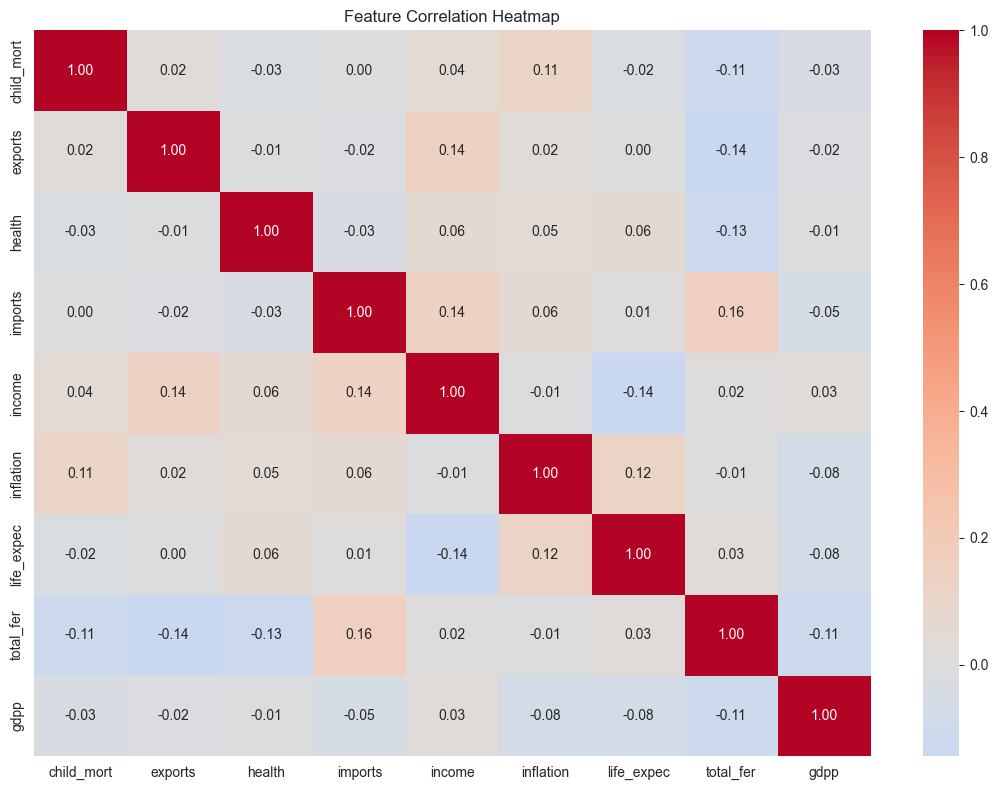

In [6]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(11, 8))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()


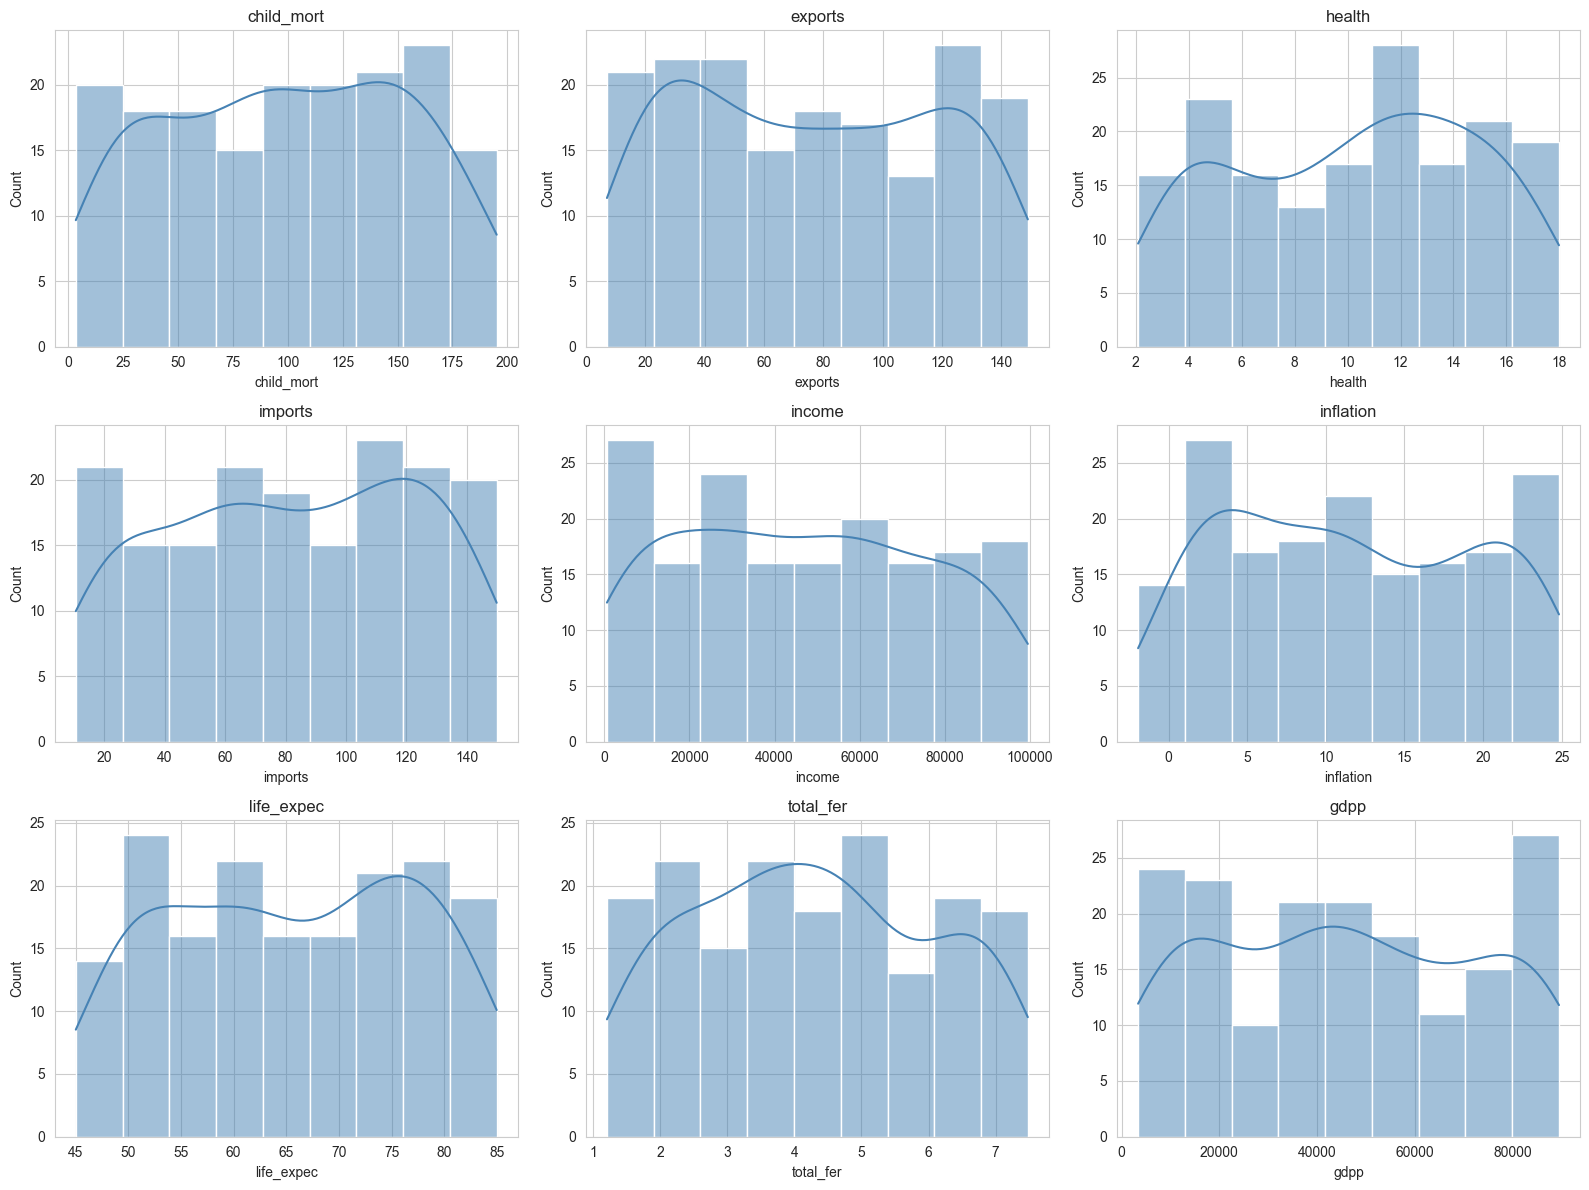

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
for ax, col in zip(axes.flatten(), numeric_cols[:9]):
    sns.histplot(df[col], kde=True, ax=ax, color="steelblue")
    ax.set_title(col)
plt.tight_layout()
plt.show()


## 4. Preprocessing

Scale numeric features so clustering and distance-based metrics aren't dominated by
large-magnitude columns like `income` or `gdpp`.


In [8]:
feature_cols = [c for c in numeric_cols]
X = df[feature_cols].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)
X_scaled_df.head()


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.020946,-0.666319,-1.318816,-1.502081,-1.344967,-1.112272,1.295760,-0.146901,0.535860
1,-0.189412,0.095386,1.545491,1.096678,-0.890765,-1.039939,0.803342,-0.343730,-0.441465
2,1.326688,-0.785101,0.994591,-1.557744,-1.511733,1.220694,1.638080,1.356720,0.369565
3,0.744297,1.526048,0.272119,-0.798155,-0.044095,1.404440,0.051269,1.711193,-1.569755
4,-1.434533,-1.095565,0.930922,-0.617513,0.566598,-0.996726,0.494444,1.348872,-0.156599


## 5. Clustering — K-Means

We use the **elbow method** and **silhouette score** to select the optimal number of
clusters (customer segments).


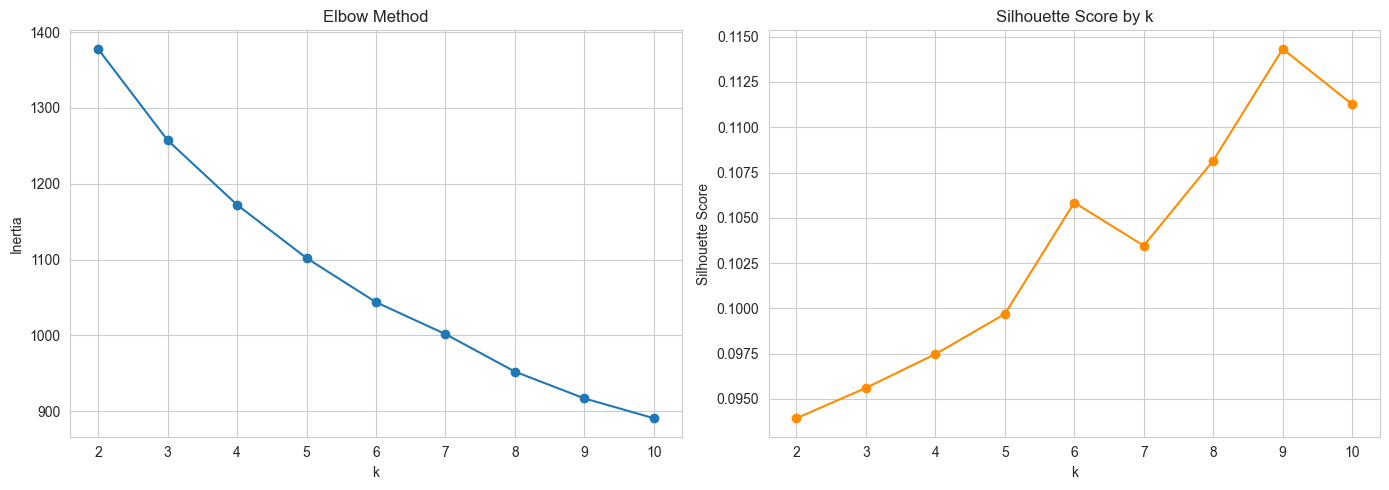

Best k by silhouette score: 9


In [9]:
inertias = []
sil_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(K_range), inertias, marker="o")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")

axes[1].plot(list(K_range), sil_scores, marker="o", color="darkorange")
axes[1].set_title("Silhouette Score by k")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette Score")
plt.tight_layout()
plt.show()

best_k = list(K_range)[np.argmax(sil_scores)]
print(f"Best k by silhouette score: {best_k}")


In [10]:
kmeans = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
df["kmeans_segment"] = kmeans.fit_predict(X_scaled)

print(f"Silhouette Score (K-Means): {silhouette_score(X_scaled, df['kmeans_segment']):.3f}")
print(f"Davies-Bouldin Index (K-Means): {davies_bouldin_score(X_scaled, df['kmeans_segment']):.3f}")
df["kmeans_segment"].value_counts().sort_index()


Silhouette Score (K-Means): 0.114
Davies-Bouldin Index (K-Means): 1.873


kmeans_segment
0    16
1    15
2    22
3    27
4    19
5    27
6    17
7    15
8    12
Name: count, dtype: int64

## 6. Clustering — DBSCAN

DBSCAN discovers density-based clusters and naturally flags outlier "customers"
(label `-1`) — useful for identifying anomalous or extreme-profile segments that
K-Means, which forces every point into a cluster, would smear into the nearest group.


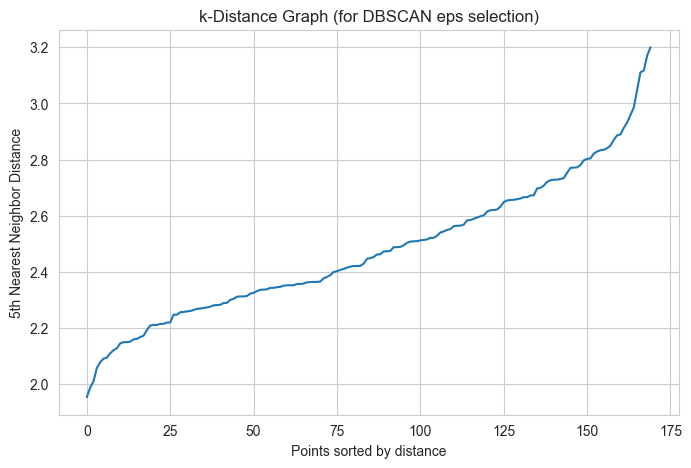

In [11]:
from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)
distances = np.sort(distances[:, -1])

plt.figure(figsize=(8, 5))
plt.plot(distances)
plt.title("k-Distance Graph (for DBSCAN eps selection)")
plt.xlabel("Points sorted by distance")
plt.ylabel("5th Nearest Neighbor Distance")
plt.show()


In [12]:
# Adjust eps based on the "elbow" of the k-distance graph above
dbscan = DBSCAN(eps=1.5, min_samples=5)
df["dbscan_segment"] = dbscan.fit_predict(X_scaled)

n_clusters = len(set(df["dbscan_segment"])) - (1 if -1 in df["dbscan_segment"].values else 0)
n_noise = list(df["dbscan_segment"]).count(-1)
print(f"DBSCAN found {n_clusters} clusters and {n_noise} noise/outlier points")

if n_clusters > 1:
    mask = df["dbscan_segment"] != -1
    print(f"Silhouette Score (DBSCAN, excl. noise): {silhouette_score(X_scaled[mask], df['dbscan_segment'][mask]):.3f}")

df["dbscan_segment"].value_counts().sort_index()


DBSCAN found 0 clusters and 170 noise/outlier points


dbscan_segment
-1    170
Name: count, dtype: int64

## 7. Visualizing Segments (PCA Projection)


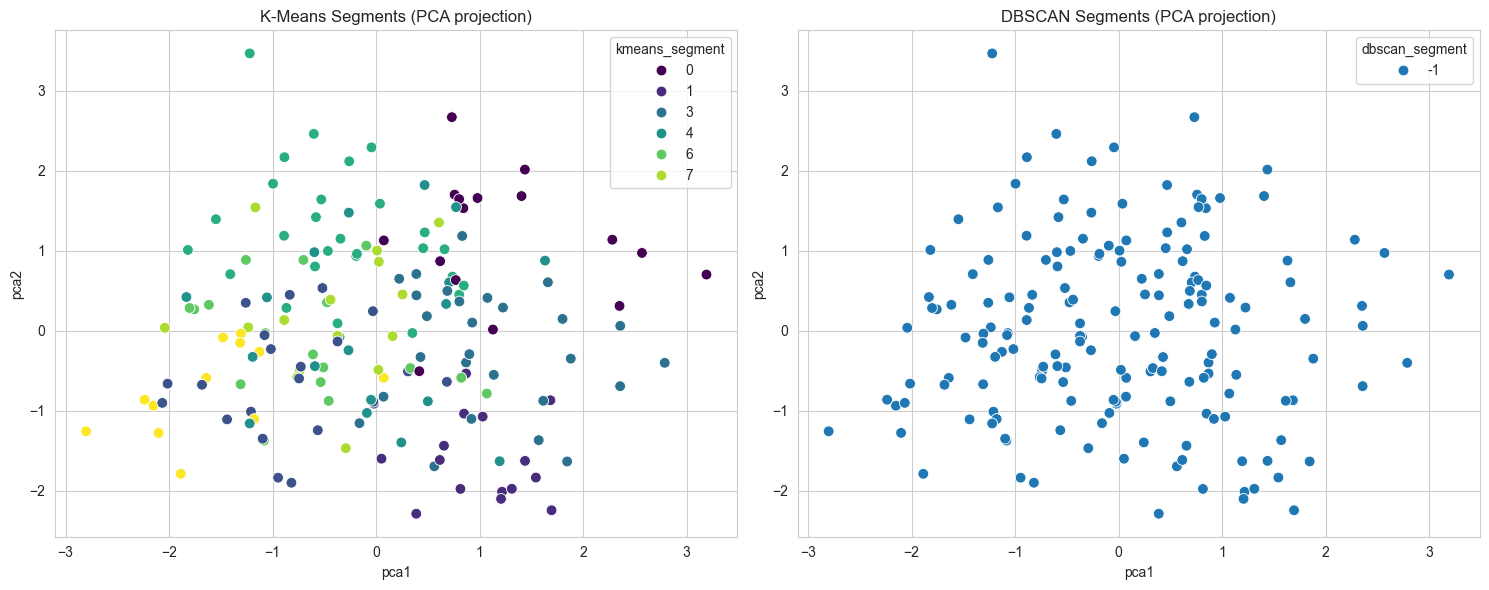

In [13]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
df["pca1"], df["pca2"] = X_pca[:, 0], X_pca[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.scatterplot(data=df, x="pca1", y="pca2", hue="kmeans_segment",
                 palette="viridis", ax=axes[0], s=60)
axes[0].set_title("K-Means Segments (PCA projection)")

sns.scatterplot(data=df, x="pca1", y="pca2", hue="dbscan_segment",
                 palette="tab10", ax=axes[1], s=60)
axes[1].set_title("DBSCAN Segments (PCA projection)")

plt.tight_layout()
plt.show()


## 8. Segment Profiling

Label each K-Means segment by its average socio-economic profile so the clusters
translate into **actionable business categories** (e.g., "High-Value", "At-Risk",
"Developing").


In [14]:
segment_profile = df.groupby("kmeans_segment")[feature_cols].mean().round(1)
segment_profile["count"] = df["kmeans_segment"].value_counts().sort_index()
segment_profile


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,count
kmeans_segment,,,,,,,,,,
0,124.3,47.9,6.7,106.5,15602.2,19.1,77.8,5.0,49888.8,16
1,80.8,64.9,5.4,112.9,71213.4,11.4,54.5,6.1,40085.3,15
2,82.7,80.4,13.4,110.2,67584.8,11.0,60.2,2.9,58576.9,22
3,90.7,49.7,12.6,101.8,56242.5,6.9,70.7,5.9,28846.4,27
4,29.2,92.3,10.1,40.6,38859.0,9.1,71.2,4.9,60939.2,19
5,109.1,105.1,13.3,78.1,43073.9,19.1,72.0,3.5,29579.0,27
6,114.0,37.0,11.9,48.0,23575.5,7.5,55.0,3.8,66405.0,17
7,138.1,88.2,6.4,60.5,26630.3,5.8,62.6,3.1,29471.5,15
8,158.3,121.8,6.0,69.5,79067.5,13.6,58.3,3.0,66793.8,12


In [15]:
# Rank segments by a composite affluence score (gdpp + income - child_mort) to assign
# human-readable tiers. Adjust the logic to match your actual business KPIs.
score = (
    segment_profile["gdpp"].rank() +
    segment_profile["income"].rank() -
    segment_profile["child_mort"].rank()
)
ordering = score.sort_values().index.tolist()

tier_names = ["Low-Value / At-Risk", "Emerging / Developing", "Core / Stable", "High-Value / Premium"]
tier_map = {seg: tier_names[i] if i < len(tier_names) else f"Tier {i}"
            for i, seg in enumerate(ordering)}

df["segment_label"] = df["kmeans_segment"].map(tier_map)
df[["country", "kmeans_segment", "segment_label"]].head(10)


,country,kmeans_segment,segment_label
0,Country_0,7,Low-Value / At-Risk
1,Country_1,3,High-Value / Premium
2,Country_2,0,Emerging / Developing
3,Country_3,5,Core / Stable
4,Country_4,3,High-Value / Premium
5,Country_5,6,Tier 4
6,Country_6,5,Core / Stable
7,Country_7,8,Tier 5
8,Country_8,4,Tier 8
9,Country_9,1,Tier 7


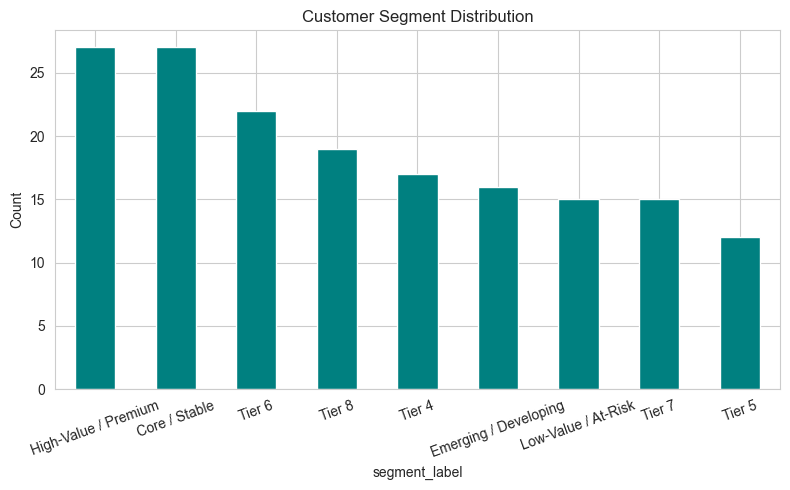

In [16]:
plt.figure(figsize=(8, 5))
df["segment_label"].value_counts().plot(kind="bar", color="teal")
plt.title("Customer Segment Distribution")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## 9. Classification — Predicting Customer Segment

With clusters established as ground-truth segment labels, we train supervised
classifiers so **new customers can be scored into a segment instantly**, without
re-running clustering every time.


In [17]:
X_clf = df[feature_cols]
y_clf = df["kmeans_segment"]

X_train, X_test, y_train, y_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=RANDOM_STATE, stratify=y_clf
)

scaler_clf = StandardScaler()
X_train_scaled = scaler_clf.fit_transform(X_train)
X_test_scaled = scaler_clf.transform(X_test)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")


Train shape: (136, 9), Test shape: (34, 9)


### 9.1 Random Forest

In [18]:
rf_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5],
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    rf_param_grid, cv=5, scoring="accuracy", n_jobs=-1
)
rf_grid.fit(X_train_scaled, y_train)

rf_best = rf_grid.best_estimator_
print("Best Random Forest params:", rf_grid.best_params_)

rf_preds = rf_best.predict(X_test_scaled)
print(f"\nRandom Forest Test Accuracy: {accuracy_score(y_test, rf_preds):.3f}")
print(classification_report(y_test, rf_preds))


Best Random Forest params: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}

Random Forest Test Accuracy: 0.706
              precision    recall  f1-score   support

           0       0.75      1.00      0.86         3
           1       0.50      0.33      0.40         3
           2       0.50      0.50      0.50         4
           3       0.50      0.83      0.62         6
           4       0.75      0.75      0.75         4
           5       1.00      0.83      0.91         6
           6       1.00      1.00      1.00         3
           7       1.00      0.33      0.50         3
           8       1.00      0.50      0.67         2

    accuracy                           0.71        34
   macro avg       0.78      0.68      0.69        34
weighted avg       0.76      0.71      0.70        34



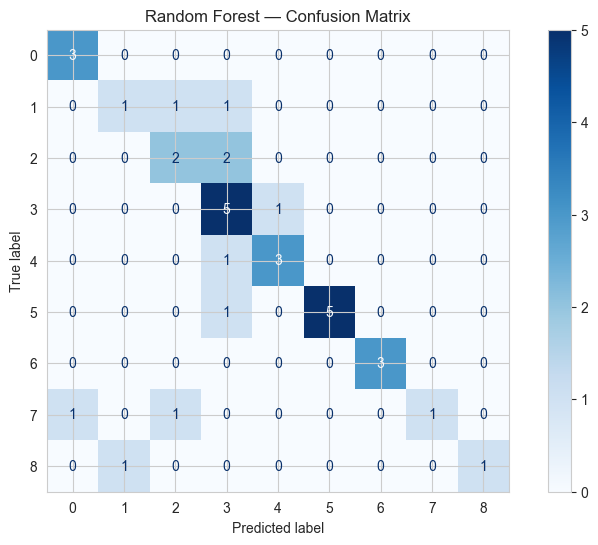

In [19]:
cm = confusion_matrix(y_test, rf_preds)
ConfusionMatrixDisplay(cm).plot(cmap="Blues")
plt.title("Random Forest — Confusion Matrix")
plt.show()


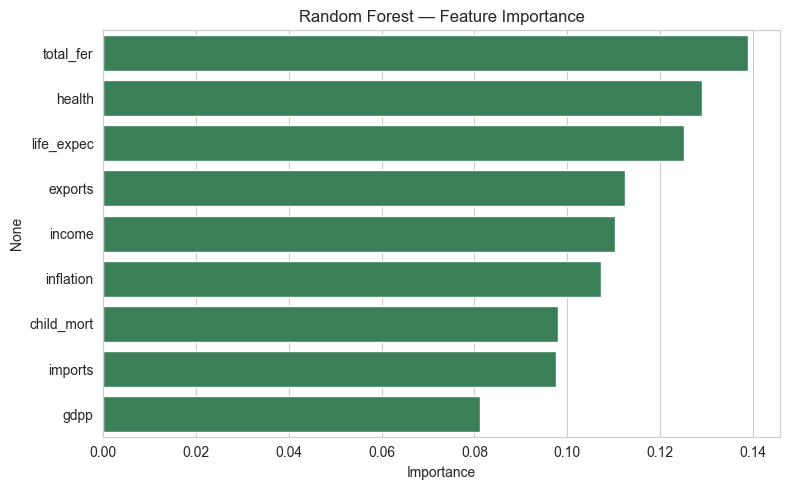

In [20]:
importances = pd.Series(rf_best.feature_importances_, index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(x=importances.values, y=importances.index, color="seagreen")
plt.title("Random Forest — Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


### 9.2 XGBoost

In [21]:
if HAS_XGB:
    xgb_param_grid = {
        "n_estimators": [100, 200],
        "max_depth": [3, 5, 7],
        "learning_rate": [0.05, 0.1, 0.2],
    }

    xgb_grid = GridSearchCV(
        XGBClassifier(random_state=RANDOM_STATE, eval_metric="mlogloss"),
        xgb_param_grid, cv=5, scoring="accuracy", n_jobs=-1
    )
    xgb_grid.fit(X_train_scaled, y_train)

    xgb_best = xgb_grid.best_estimator_
    print("Best XGBoost params:", xgb_grid.best_params_)

    xgb_preds = xgb_best.predict(X_test_scaled)
    print(f"\nXGBoost Test Accuracy: {accuracy_score(y_test, xgb_preds):.3f}")
    print(classification_report(y_test, xgb_preds))
else:
    print("Install xgboost to run this cell: pip install xgboost")


Best XGBoost params: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 200}

XGBoost Test Accuracy: 0.706
              precision    recall  f1-score   support

           0       0.75      1.00      0.86         3
           1       0.33      0.33      0.33         3
           2       1.00      0.50      0.67         4
           3       0.67      0.67      0.67         6
           4       0.60      0.75      0.67         4
           5       0.83      0.83      0.83         6
           6       1.00      1.00      1.00         3
           7       0.50      0.67      0.57         3
           8       1.00      0.50      0.67         2

    accuracy                           0.71        34
   macro avg       0.74      0.69      0.70        34
weighted avg       0.74      0.71      0.70        34



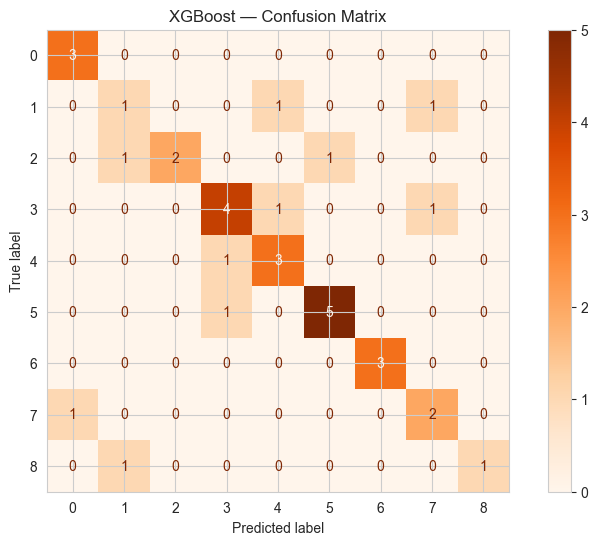

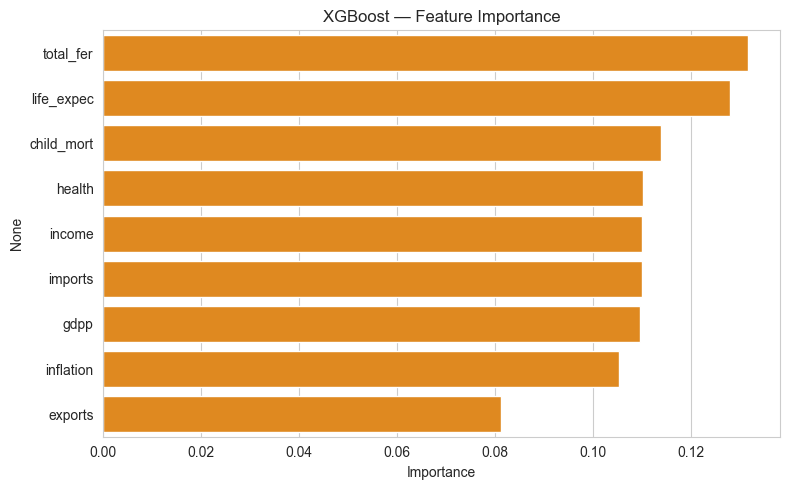

In [22]:
if HAS_XGB:
    cm_xgb = confusion_matrix(y_test, xgb_preds)
    ConfusionMatrixDisplay(cm_xgb).plot(cmap="Oranges")
    plt.title("XGBoost — Confusion Matrix")
    plt.show()

    importances_xgb = pd.Series(xgb_best.feature_importances_, index=feature_cols).sort_values(ascending=False)
    plt.figure(figsize=(8, 5))
    sns.barplot(x=importances_xgb.values, y=importances_xgb.index, color="darkorange")
    plt.title("XGBoost — Feature Importance")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()


## 10. Model Comparison


In [23]:
results = {"Random Forest": accuracy_score(y_test, rf_preds)}
if HAS_XGB:
    results["XGBoost"] = accuracy_score(y_test, xgb_preds)

results_df = pd.DataFrame(list(results.items()), columns=["Model", "Test Accuracy"])
results_df = results_df.sort_values("Test Accuracy", ascending=False).reset_index(drop=True)
results_df


,Model,Test Accuracy
0,Random Forest,0.705882
1,XGBoost,0.705882


C:\Users\sayan\AppData\Local\Temp\ipykernel_13068\3046061493.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Model", y="Test Accuracy", palette="mako")


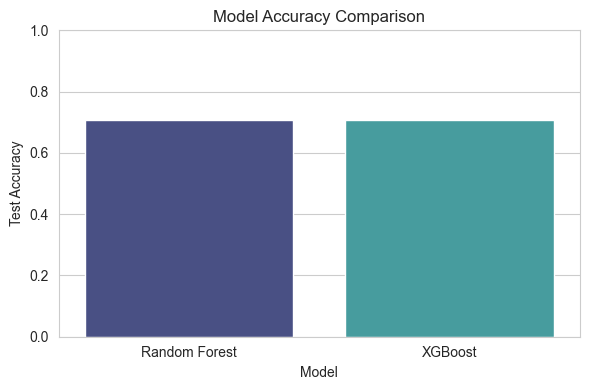

In [24]:
plt.figure(figsize=(6, 4))
sns.barplot(data=results_df, x="Model", y="Test Accuracy", palette="mako")
plt.ylim(0, 1)
plt.title("Model Accuracy Comparison")
plt.tight_layout()
plt.show()


In [25]:
# 5-fold CV comparison for a more robust estimate than a single train/test split
cv_rf = cross_val_score(rf_best, X_scaled, y_clf, cv=5, scoring="accuracy")
print(f"Random Forest CV Accuracy: {cv_rf.mean():.3f} +/- {cv_rf.std():.3f}")

if HAS_XGB:
    cv_xgb = cross_val_score(xgb_best, X_scaled, y_clf, cv=5, scoring="accuracy")
    print(f"XGBoost CV Accuracy: {cv_xgb.mean():.3f} +/- {cv_xgb.std():.3f}")


Random Forest CV Accuracy: 0.729 +/- 0.051
XGBoost CV Accuracy: 0.676 +/- 0.056


## 11. Actionable Insights

Summary of what a business/analytics team could do with these segments:

- **High-Value / Premium segment** — prioritize retention programs, premium support,
  and upsell campaigns; this group drives disproportionate revenue/value.
- **Core / Stable segment** — the largest, steady base; focus on efficient, scaled
  engagement (email/lifecycle marketing) rather than high-touch outreach.
- **Emerging / Developing segment** — strong growth candidates; targeted nurture
  campaigns and education content can migrate them toward the Core/High-Value tiers.
- **Low-Value / At-Risk segment** — flag for churn-prevention workflows or
  cost-to-serve review; DBSCAN's noise points within this group are worth a manual
  audit as they may represent anomalies (fraud, data errors) rather than a true segment.
- **Random Forest vs. XGBoost** — compare not just accuracy but also training time and
  interpretability; Random Forest is often more robust out-of-the-box, while XGBoost
  typically edges ahead after hyperparameter tuning on structured/tabular data like this.
- **Operationalizing** — the trained classifier lets new customers be scored into a
  segment immediately at signup/onboarding, without waiting to re-run clustering on
  the full dataset.

### Next steps
- Swap in real customer-level data (RFM: recency, frequency, monetary value; support
  tickets; engagement events) alongside or instead of the country indicators for a
  production-grade Customer Intelligence System.
- Add a time dimension to track segment migration (customers moving tiers over time).
- Deploy the trained classifier behind an API endpoint for real-time segment scoring.
